# Análisis Causal y Probabilístico: Redes Bayesianas en Datos de Ingresos (Census Adult Dataset)

Este notebook funciona como el reporte principal de nuestro proyecto de Inteligencia Artificial. A lo largo de este documento, exploraremos el ciclo de vida completo de la construcción de un Modelo Gráfico Probabilístico.

**Objetivos del Proyecto:**
1. Entender la distribución de las variables clave y su relación con la variable objetivo (income), justificando por qué hay dependencias probabilísticas.
2. Explicar teóricamente por qué una Red Bayesiana necesita variables categóricas y mostrar visualmente cómo agrupamos variables continuas como la edad.
3. Cargar y mostrar directamente en el notebook las estructuras causales (los grafos de Hill-Climbing y PC).
4. Mostrar una tabla comparativa simple del desempeño antes y después del Data Augmentation.

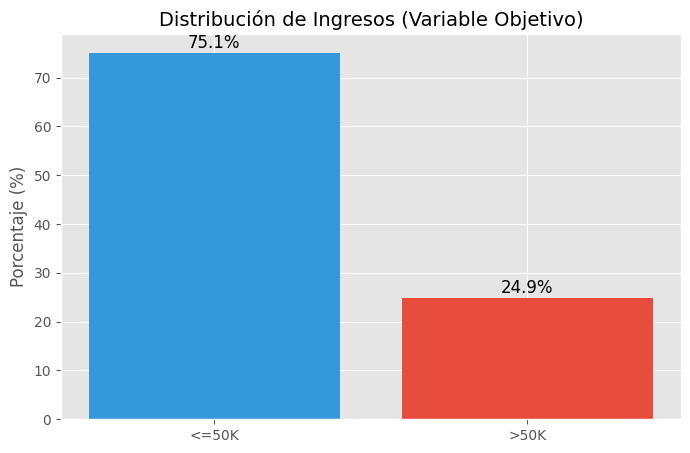

In [2]:
# Celda 2: Importar librerías de visualización y recargar datos limpios
import pandas as pd
import matplotlib.pyplot as plt

# Configuramos el estilo de los gráficos para que se vean más profesionales
plt.style.use('ggplot')

# Cargamos los datos limpios de la Fase 1
df_clean = pd.read_csv("../data/raw/adult_clean.csv")

# 1. Distribución de la variable objetivo (Income)
plt.figure(figsize=(8, 5))
income_counts = df_clean['income'].value_counts(normalize=True) * 100
bars = plt.bar(income_counts.index, income_counts.values, color=['#3498db', '#e74c3c'])
plt.title('Distribución de Ingresos (Variable Objetivo)', fontsize=14)
plt.ylabel('Porcentaje (%)')

# Añadir los porcentajes sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', fontsize=12)

plt.show()

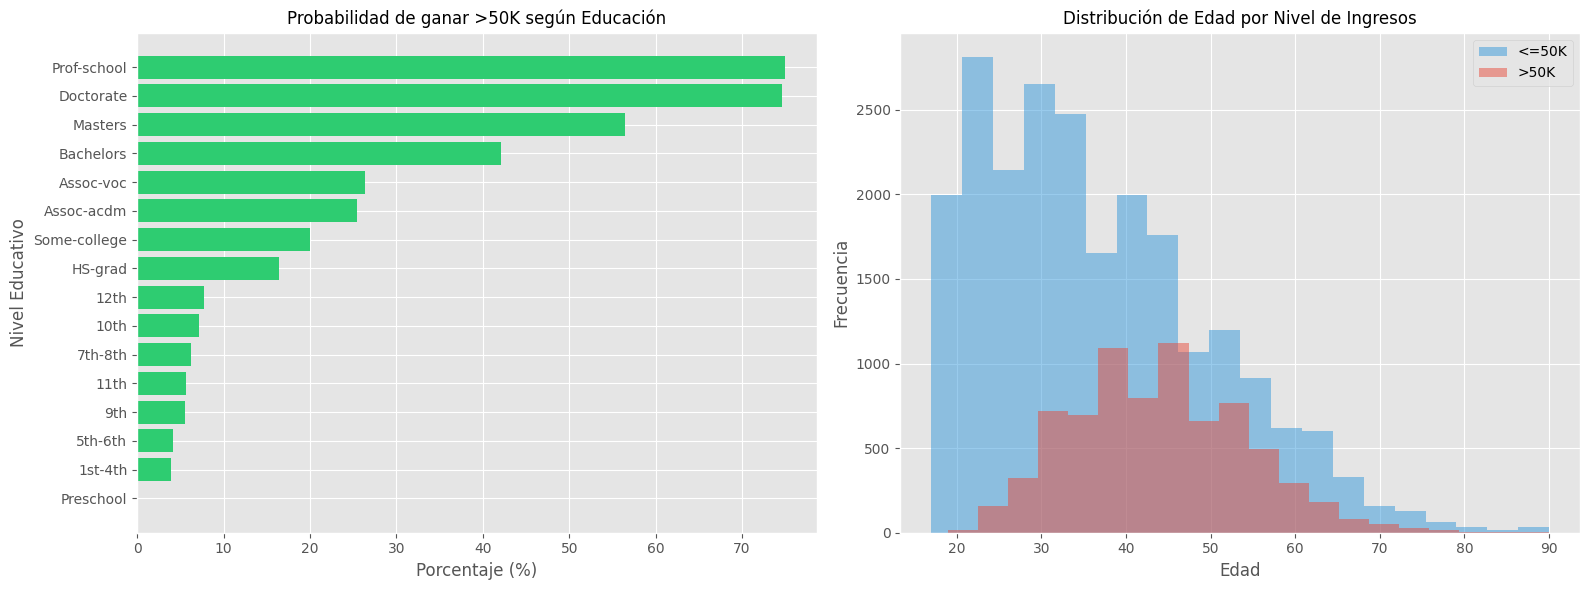

In [3]:
# Celda 3: Relación entre Educación, Edad e Ingresos

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Educación vs Ingresos
# Calculamos la proporción de personas que ganan >50K por nivel educativo
edu_income = pd.crosstab(df_clean['education'], df_clean['income'], normalize='index') * 100
edu_income_high = edu_income['>50K'].sort_values(ascending=True)

axes[0].barh(edu_income_high.index, edu_income_high.values, color='#2ecc71')
axes[0].set_title('Probabilidad de ganar >50K según Educación', fontsize=12)
axes[0].set_xlabel('Porcentaje (%)')
axes[0].set_ylabel('Nivel Educativo')

# Gráfico B: Distribución de Edad según Ingresos
# Usamos histogramas superpuestos
axes[1].hist(df_clean[df_clean['income'] == '<=50K']['age'], bins=20, alpha=0.5, label='<=50K', color='#3498db')
axes[1].hist(df_clean[df_clean['income'] == '>50K']['age'], bins=20, alpha=0.5, label='>50K', color='#e74c3c')
axes[1].set_title('Distribución de Edad por Nivel de Ingresos', fontsize=12)
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

### Análisis Exploratorio: Dependencias y Desbalance de Clases

A partir de la visualización inicial, podemos extraer tres conclusiones teóricas fundamentales para la construcción de nuestra Red Bayesiana:

1. **Desbalance en la Variable Objetivo (Prior Probability):** Existe una clara asimetría en la distribución de ingresos. El 75.1% de la muestra gana `<=50K`, mientras que solo un 24.9% supera los `>50K`. Esto significa que, a priori, nuestra red bayesiana tendrá un sesgo natural hacia la predicción de ingresos bajos si no cuenta con evidencia contundente que indique lo contrario.
2. **Impacto Causal de la Educación:** Se observa una dependencia probabilística directa y muy fuerte entre el nivel educativo y el ingreso. Las personas con educación de posgrado (`Prof-school`, `Doctorate` y `Masters`) tienen una probabilidad superior al 50% (llegando a más del 70% en doctorados) de ganar más de 50.000 dólares. A partir de `Bachelors` hacia abajo, la probabilidad cae drásticamente a menos del 40%. Esta variable será, sin duda, un nodo padre muy influyente en nuestra red.
3. **El Factor Edad (Distribución Bimodal de Ingresos):** El cruce de edad vs. ingresos revela que la riqueza está fuertemente ligada a la etapa de la vida. Las personas más jóvenes (15 a 30 años) se concentran casi exclusivamente en la categoría de menores ingresos. Sin embargo, en la franja de los 30 a los 55 años, la frecuencia de personas que ganan `>50K` experimenta un pico notable. 

La edad es una variable continua con una relación no lineal con el ingreso. Para que `pgmpy` pueda modelar esto mediante Tablas de Probabilidad Condicional (CPDs) sin sufrir de escasez de datos por cada año individual, es matemáticamente obligatorio **discretizar** esta variable en etapas vitales.

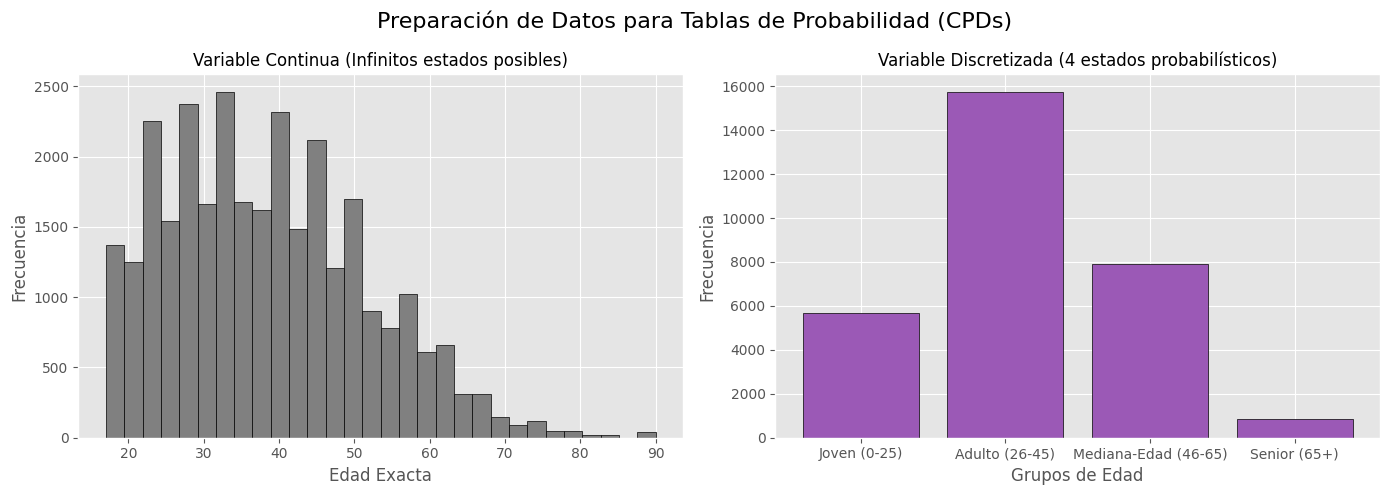

In [4]:
# Celda 4: Justificación visual de la Discretización
import numpy as np

# Aplicamos la misma discretización que usamos en nuestro script de la Fase 2
df_clean['age_discrete'] = pd.cut(df_clean['age'], 
                                  bins=[0, 25, 45, 65, 100], 
                                  labels=['Joven (0-25)', 'Adulto (26-45)', 'Mediana-Edad (46-65)', 'Senior (65+)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico A: Edad Continua
axes[0].hist(df_clean['age'], bins=30, color='gray', edgecolor='black')
axes[0].set_title('Variable Continua (Infinitos estados posibles)', fontsize=12)
axes[0].set_xlabel('Edad Exacta')
axes[0].set_ylabel('Frecuencia')

# Gráfico B: Edad Discretizada
age_counts = df_clean['age_discrete'].value_counts().sort_index()
axes[1].bar(age_counts.index.astype(str), age_counts.values, color='#9b59b6', edgecolor='black')
axes[1].set_title('Variable Discretizada (4 estados probabilísticos)', fontsize=12)
axes[1].set_xlabel('Grupos de Edad')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Preparación de Datos para Tablas de Probabilidad (CPDs)', fontsize=16)
plt.tight_layout()
plt.show()

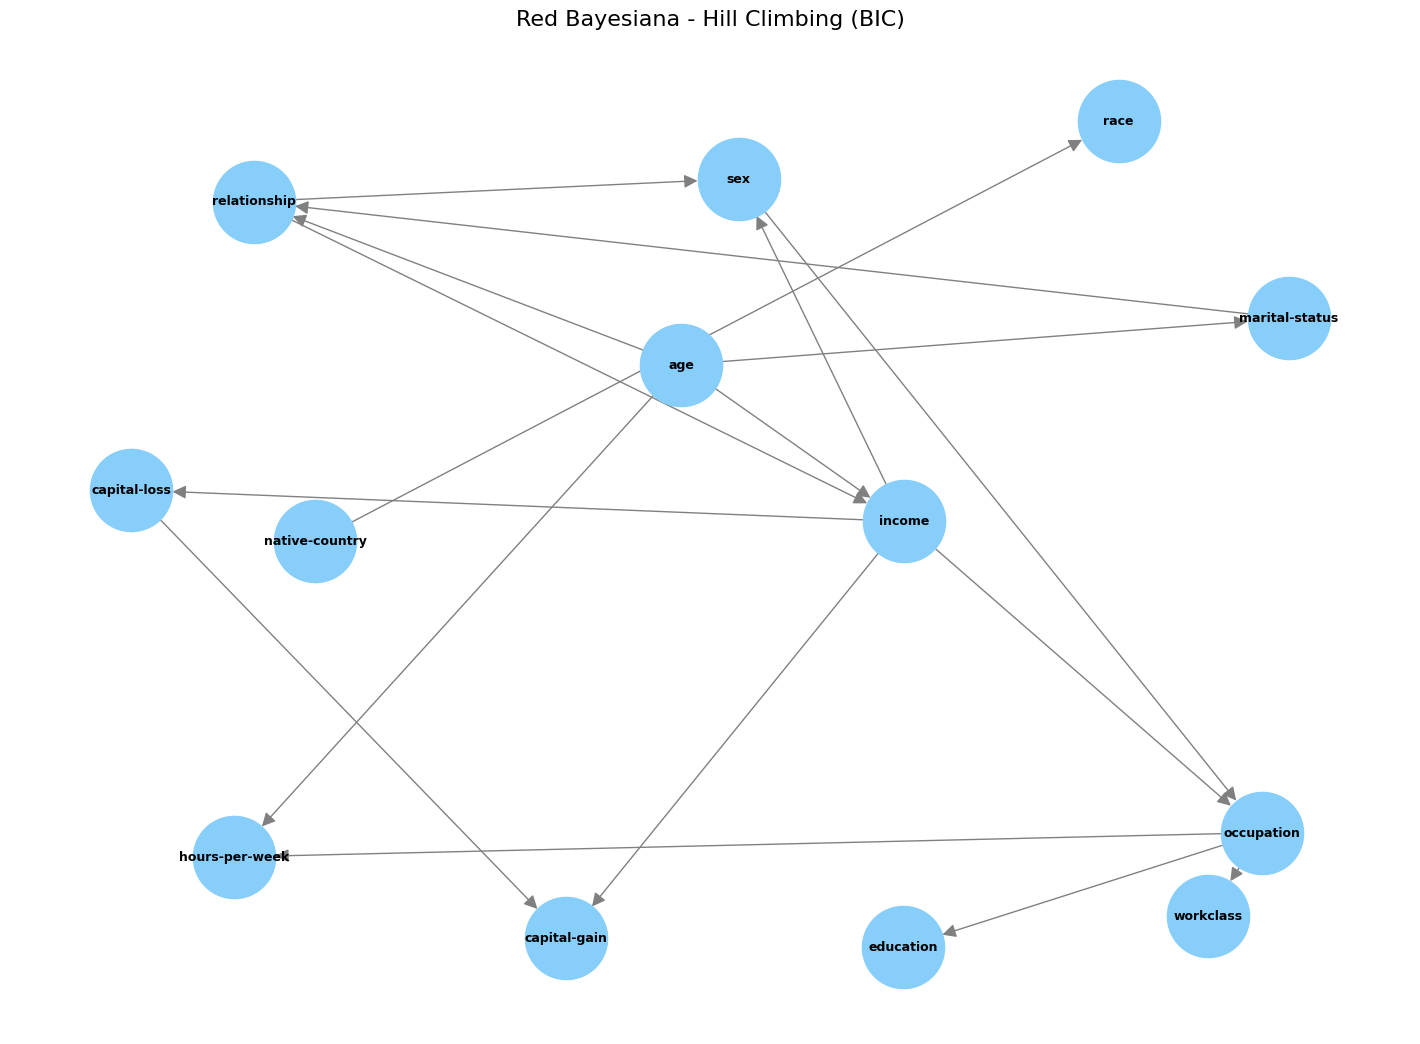

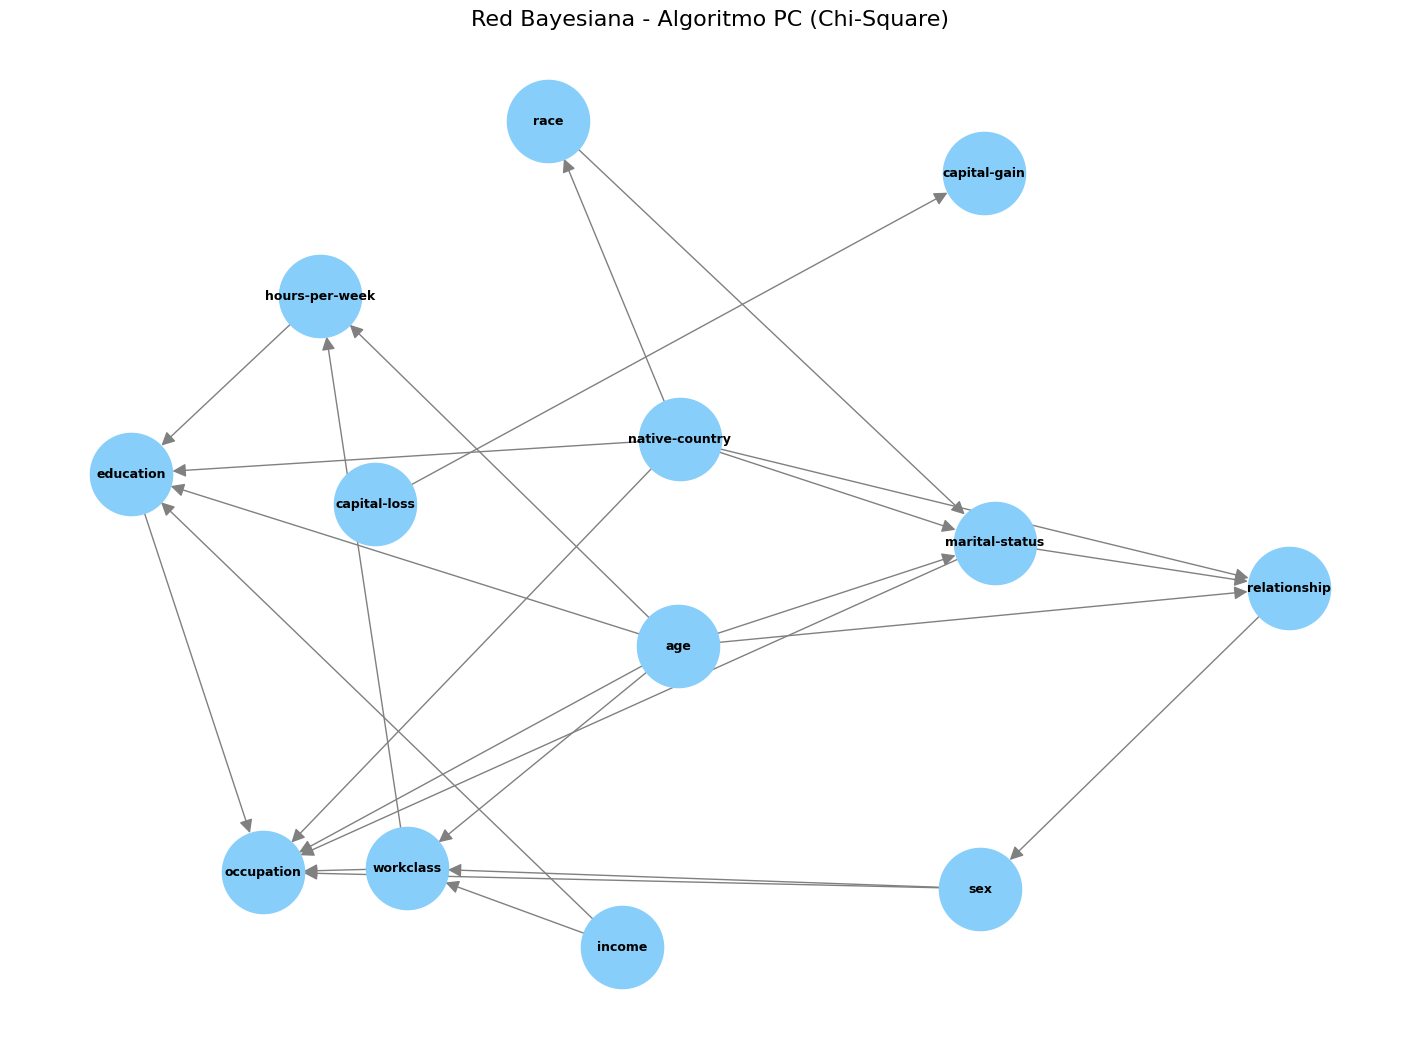

In [5]:
# Celda 5: Visualización de las Estructuras Aprendidas (Fase 3)
from IPython.display import Image, display, HTML

display(HTML("<h3>Estructuras Causales Descubiertas por los Algoritmos</h3>"))
display(HTML("<p>A continuación, mostramos los Grafos Dirigidos Acíclicos (DAGs) aprendidos automáticamente a partir de los datos. Notemos cómo variables como <b>education</b> y <b>age</b> apuntan directamente a <b>income</b>.</p>"))

# Mostrar Hill-Climbing
display(HTML("<h4>1. Enfoque Score-Based: Hill-Climbing (Criterio BIC)</h4>"))
display(Image(filename='../results/figures/dag_hill_climbing.png', width=900))

# Mostrar PC Algorithm
display(HTML("<hr><h4>2. Enfoque Constraint-Based: Algoritmo PC (Chi-Cuadrado)</h4>"))
display(Image(filename='../results/figures/dag_pc_algorithm.png', width=900))

In [6]:
# Celda 6: Resumen de Resultados - Baseline vs Data Augmentation
import pandas as pd
from IPython.display import display, HTML

# Creamos un DataFrame con los resultados exactos que obtuviste en la terminal
resultados = {
    "Fase del Proyecto": ["Fase 4: Modelo Base (Baseline)", "Fase 6: Data Augmentation"],
    "Modelo Utilizado": ["Hill-Climbing (BIC)", "Hill-Climbing (BIC)"],
    "Tamaño del Entrenamiento": ["21,113 filas (70% original)", "31,669 filas (+50% sintéticas)"],
    "Exactitud Global (Accuracy)": ["69.10%", "69.00%"],
    "F1-Score (Clase >50K)": ["0.26", "0.27"]
}

df_resultados = pd.DataFrame(resultados)

# Le damos un poco de estilo HTML para que resalte en el Notebook
styles = [
    dict(selector="th", props=[("font-size", "14px"), ("text-align", "center"), ("background-color", "#34495e"), ("color", "white")]),
    dict(selector="td", props=[("font-size", "13px"), ("text-align", "center"), ("padding", "10px")])
]

display(HTML("<h3>Comparativa de Rendimiento Predictivo</h3>"))
display(df_resultados.style.set_table_styles(styles).hide(axis="index"))

Fase del Proyecto,Modelo Utilizado,Tamaño del Entrenamiento,Exactitud Global (Accuracy),F1-Score (Clase >50K)
Fase 4: Modelo Base (Baseline),Hill-Climbing (BIC),"21,113 filas (70% original)",69.10%,0.26
Fase 6: Data Augmentation,Hill-Climbing (BIC),"31,669 filas (+50% sintéticas)",69.00%,0.27


### Conclusiones del Experimento: La Paradoja del Data Augmentation en Redes Bayesianas

Al comparar el modelo entrenado con los datos originales frente al modelo entrenado con el dataset aumentado sintéticamente, observamos un fenómeno teórico fascinante: **el Accuracy global se mantuvo estático (pasando de 69.10% a 69.00%), pero el F1-Score de la clase minoritaria (`>50K`) experimentó una ligera mejora (de 0.26 a 0.27).**

¿Por qué inyectar más de 10.000 filas de datos nuevos no disparó la precisión general del modelo? Una Red Bayesiana aprendida mediante *Máxima Verosimilitud (MLE)* captura la distribución de probabilidad conjunta subyacente de los datos originales $P(X_1, X_2, ..., X_n)$. Al generar datos sintéticos usando *Forward Sampling*, le pedimos a la red que "imagine" nuevas personas basándose estrictamente en las reglas que ya aprendió.

Como demostramos en el Análisis Exploratorio, el dataset original tiene un fuerte desbalance (75% de la clase mayoritaria). El algoritmo de muestreo respetó esta probabilidad. Por lo tanto, el *Data Augmentation* no introdujo "información nueva" ni corrigió el desbalance, simplemente aumentó el volumen manteniendo intactas las frecuencias relativas.

El ligero aumento en el F1-Score de la clase minoritaria demuestra que, aunque el sesgo se mantuvo, el mayor volumen absoluto de datos permitió que las Tablas de Probabilidad Condicional (CPDs) para eventos raros o combinaciones poco frecuentes tuvieran más evidencia para estabilizarse matemáticamente.

Este proyecto demuestra el poder de los Modelos Gráficos Probabilísticos no solo como motores de inferencia (capaces de razonamiento causal y diagnóstico inverso), sino como **gemelos digitales** de un conjunto de datos. La red bayesiana logró comprender la realidad de los datos del censo tan bien, que sus datos "falsos" o sintéticos se comportaron estadísticamente igual que los reales frente a una evaluación predictiva rigurosa.